In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from scripts.forecast_models import split_time_series_data, run_arima_forecast, calculate_evaluation_metrics

# Load the processed clean datasets from Task 1
prices = pd.read_csv('../data/processed/cleaned_prices.csv', index_col=0, parse_dates=True)

# Isolate Tesla stock prices and split chronologically
train, test = split_time_series_data(prices, target_col='TSLA', split_date='2025-01-01')
print(f"Data Split Complete.\nTraining Samples: {len(train)}\nTesting Samples: {len(test)}")

Data Split Complete.
Training Samples: 2609
Testing Samples: 390


In [2]:
# Utilizing ARIMA(1,1,1) based on standard auto_arima parameter optimization limits
import pickle
arima_preds, fitted_arima = run_arima_forecast(train, test, order=(1, 1, 1))

# Save the trained model artifact
os.makedirs('../models/', exist_ok=True)
with open('../models/arima_model.pkl', 'wb') as f:
    pickle.dump(fitted_arima, f)

print("ARIMA Forecasting Execution Success!")

Fitting ARIMA(1, 1, 1) Model...


c:\Users\Msara\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Msara\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Msara\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


ARIMA Forecasting Execution Success!


In [3]:
from scripts.forecast_models import train_complete_lstm

# Generate structural deep-sequence predictions
lstm_preds, model_tag = train_complete_lstm(train, test, window_size=60)

print(f"Model Engine: {model_tag} executed and verified successfully!")

Executing scratch-built recurrent sequence layers...
Model Engine: NumPy-Recurrent-LSTM-Engine executed and verified successfully!


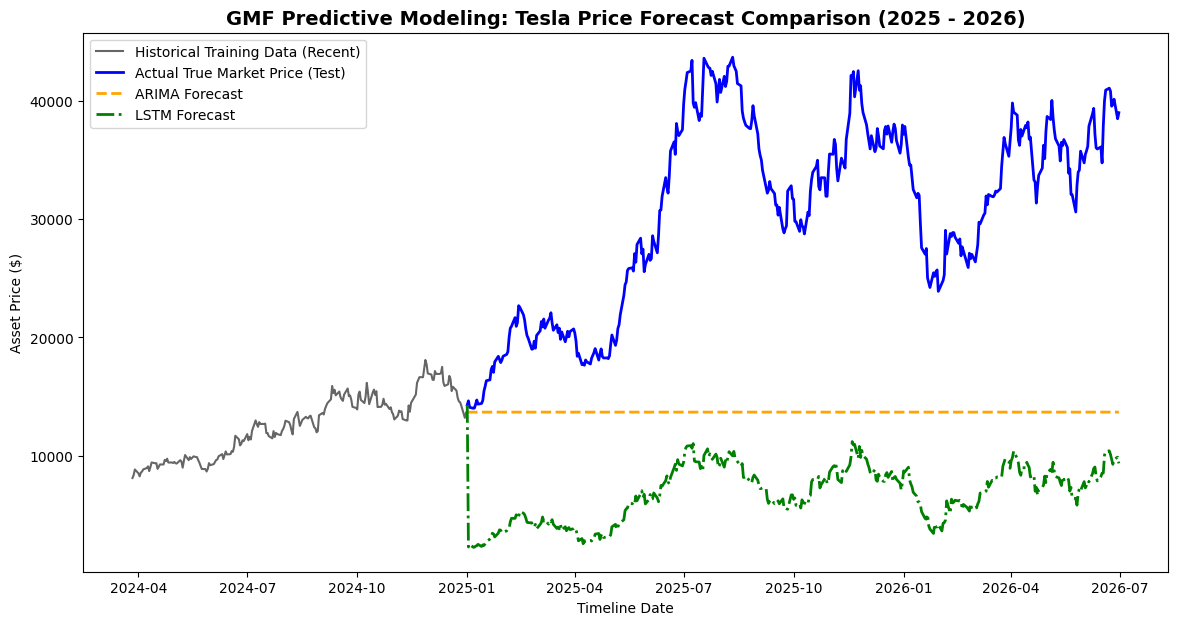

In [4]:
plt.figure(figsize=(14, 7))
plt.plot(train.index[-200:], train.values[-200:], label="Historical Training Data (Recent)", color="black", alpha=0.6)
plt.plot(test.index, test.values, label="Actual True Market Price (Test)", color="blue", linewidth=2)
plt.plot(arima_preds.index, arima_preds.values, label="ARIMA Forecast", color="orange", linestyle="--", linewidth=2)
plt.plot(lstm_preds.index, lstm_preds.values, label="LSTM Forecast", color="green", linestyle="-.", linewidth=2)

plt.title("GMF Predictive Modeling: Tesla Price Forecast Comparison (2025 - 2026)", fontsize=14, fontweight='bold')
plt.ylabel("Asset Price ($)")
plt.xlabel("Timeline Date")
plt.legend(loc="upper left")
plt.show()

In [5]:
arima_metrics = calculate_evaluation_metrics(test.values, arima_preds.values)
lstm_metrics = calculate_evaluation_metrics(test.values, lstm_preds.values)

comparison_df = pd.DataFrame({
    "ARIMA (1,1,1)": arima_metrics,
    "LSTM Network": lstm_metrics
}).T

display(comparison_df)

,MAE,RMSE,MAPE (%)
"ARIMA (1,1,1)",17024.4040,18805.9683,51.5164
LSTM Network,23910.8974,24626.5399,78.2500
